### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pydicom as dicom
import pydicom
import json
import glob
import collections
from pydicom.pixel_data_handlers.util import apply_voi_lut
import cv2
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import random
from glob import glob
import warnings
warnings.filterwarnings("ignore")


### Load & | | Read Data

In [2]:
label_coordinates_df = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_label_coordinates.csv')
train_series = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_series_descriptions.csv')
df_train = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train.csv')
df_sub = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\sample_submission.csv')
test_series = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\test_series_descriptions.csv')

In [3]:
label_coordinates_df.shape

(48692, 7)

In [4]:
label_coordinates_df.head()

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


### Loading Image

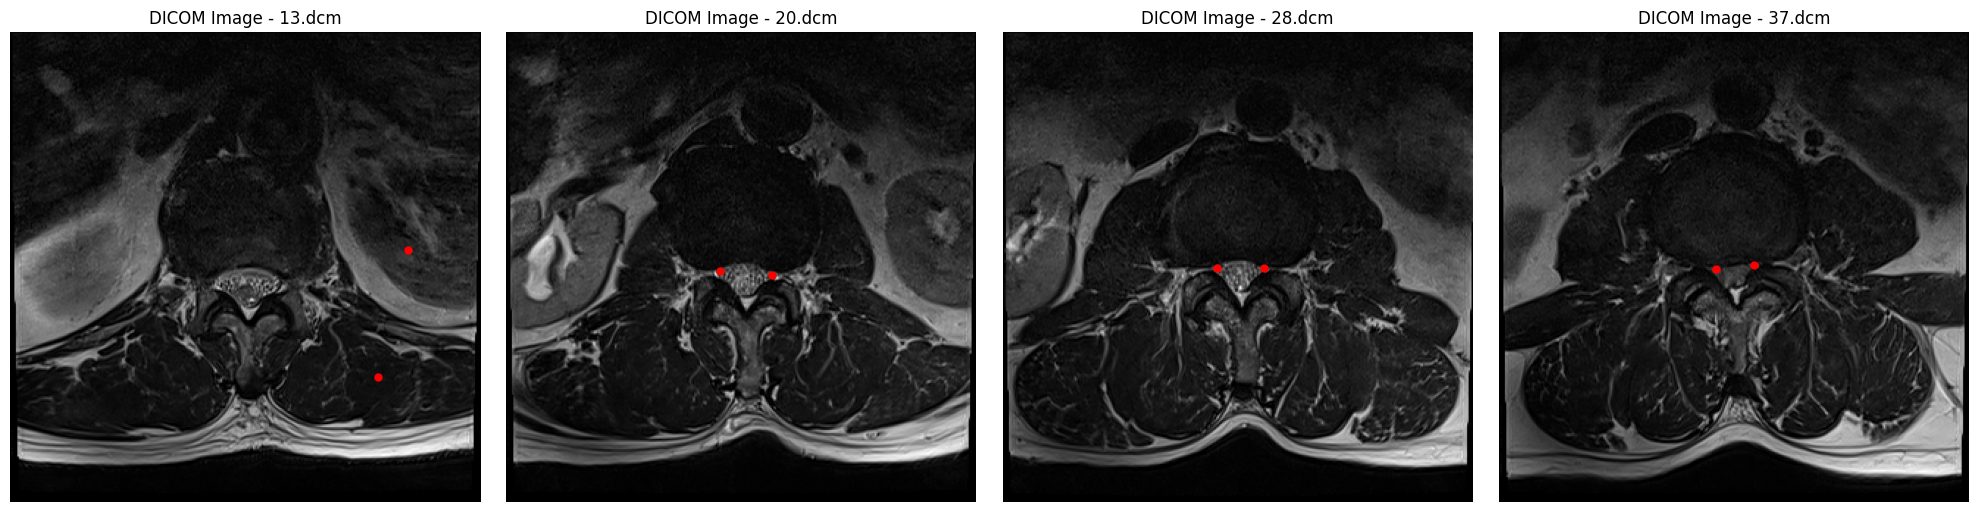

In [5]:
folder_path = 'C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_images\\100206310\\1012284084'
dicom_files = [f for f in os.listdir(folder_path) if f.endswith('.dcm') ]
label_coordinates_df = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_label_coordinates.csv')

study_id = folder_path.split('\\')[-2]
study_label_coordinates = label_coordinates_df[label_coordinates_df['study_id'] == int(study_id)]
filtered_dicom_files = []
filtered_label_coordinates = []

for dicom_file in dicom_files:
    instance_number = int(dicom_file.split('.')[0])
    corresponding_coordinates = study_label_coordinates[study_label_coordinates['instance_number'] == instance_number]
    if not corresponding_coordinates.empty:
        filtered_dicom_files.append(dicom_file)
        filtered_label_coordinates.append(corresponding_coordinates)

fig,axs = plt.subplots(1,4,figsize=(20,5))
second_row_index =1
second_row_images = filtered_dicom_files[second_row_index:second_row_index+4]
second_row_coordinates = filtered_label_coordinates[second_row_index:second_row_index+4]

for i, (dicom_file, label_coordinates) in enumerate(zip(second_row_images, second_row_coordinates)):
    dicom_path = os.path.join(folder_path, dicom_file)
    ds = pydicom.dcmread(dicom_path)
    image = ds.pixel_array
    axs[i].imshow(image, cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f'DICOM Image - {dicom_file}')
    
    for _, row in label_coordinates.iterrows():
        axs[i].plot(row['x'],row['y'],'ro',markersize=5)
plt.tight_layout()
plt.show()

In [6]:
df_train.head()

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild


In [7]:
def load_dicom(path):
    dicom=pydicom.read_file(path)
    data = dicom.pixel_array
    data = data - np.min(data)
    if np.max(data) != 0:
        data = data / np.max(data)
    data = (data * 255).astype(np.uint8)
    return data

### Animated View of Images

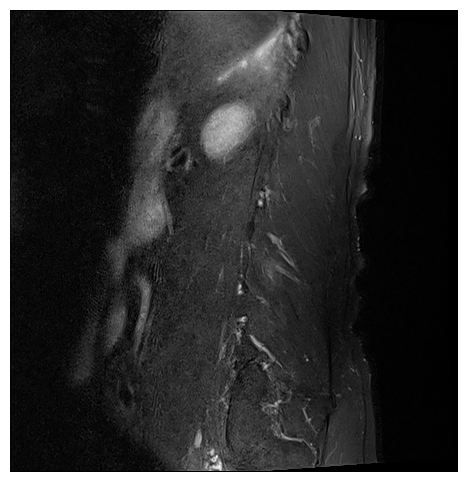

In [10]:
import glob
from matplotlib import animation,rc

rc('animation', html='jshtml')

def load_dicom(filename):
    ds = pydicom.dcmread(filename)
    return ds.pixel_array

def load_dicom_line(path):
    t_paths = sorted(
        glob.glob(os.path.join(path,"*")),
        key = lambda x: int(os.path.splitext(os.path.basename(x))[0].split("-")[-1])
    )
    images = []
    for filename in t_paths:
        data = load_dicom(filename)
        if data.max() == 0:
            continue
        images.append(data)
    return images

def create_animation(ims):
    fig = plt.figure(figsize=(6,6))
    plt.axis('off')
    im = plt.imshow(ims[0],cmap='gray')

    def animate_func(i):
        im.set_array(ims[i])
        return [im]
    
    return animation.FuncAnimation(fig, animate_func, frames=len(ims), interval=1000/24)

path_to_folder = 'C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_images\\100206310\\1792451510'
images = load_dicom_line(path_to_folder)
anim = create_animation(images)
anim

### 3D View of Images

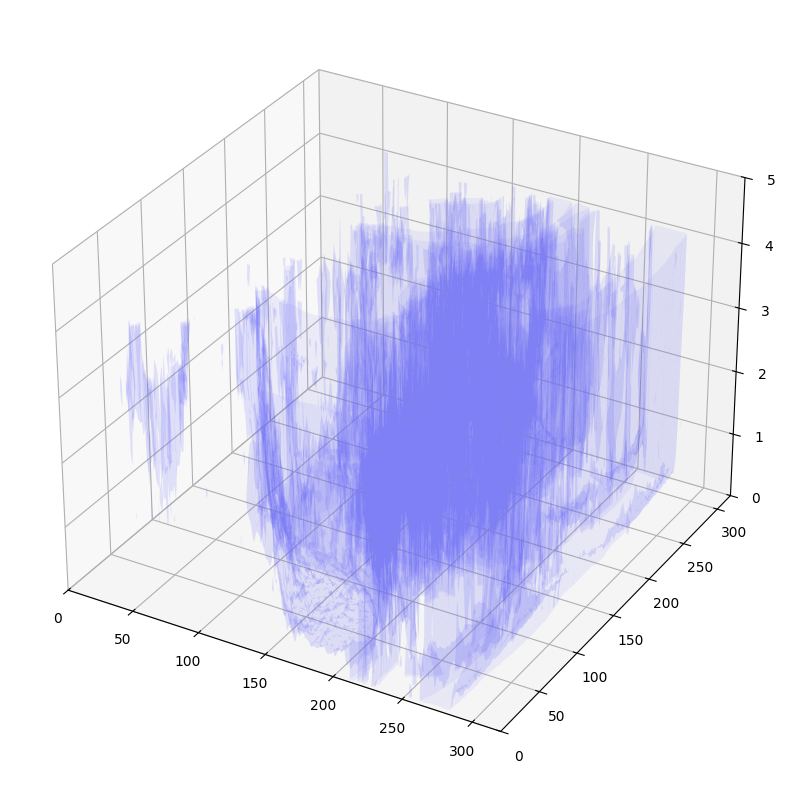

In [12]:
def load_dicom_images(folder_path, num_images=5):
    dicom_files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.dcm')])[:num_images]
    images = [pydicom.dcmread(f).pixel_array for f in dicom_files]
    return np.stack(images, axis=-1)

def plot_3d(image, threshold=-300):

    verts, faces, _, _ = measure.marching_cubes(image, level=threshold)  
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')    
    
    mesh = Poly3DCollection(verts[faces], alpha=0.1)
    face_color = [0.5, 0.5, 1]  # light blue
    mesh.set_facecolor(face_color)
    ax.add_collection3d(mesh)
    
    ax.set_xlim(0, image.shape[0])
    ax.set_ylim(0, image.shape[1])
    ax.set_zlim(0, image.shape[2])
    
    plt.show()


folder_path = "C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\train_images\\100206310\\1012284084"
dicom_images = load_dicom_images(folder_path, num_images=5)
plot_3d(dicom_images, threshold=300)


### Simple Data Preparation
### Training/Prediction

In [18]:
df_sub.head()

,row_id,normal_mild,moderate,severe
0,44036939_left_neural_foraminal_narrowing_l1_l2,0.333333,0.333333,0.333333
1,44036939_left_neural_foraminal_narrowing_l2_l3,0.333333,0.333333,0.333333
2,44036939_left_neural_foraminal_narrowing_l3_l4,0.333333,0.333333,0.333333
3,44036939_left_neural_foraminal_narrowing_l4_l5,0.333333,0.333333,0.333333
4,44036939_left_neural_foraminal_narrowing_l5_s1,0.333333,0.333333,0.333333


In [19]:
df_sub.shape,test_series.shape,train_series.shape,label_coordinates_df.shape,df_train.shape

((25, 4), (3, 3), (6294, 3), (48692, 7), (1975, 26))

In [20]:
test_series.head()

,study_id,series_id,series_description
0,44036939,2828203845,Sagittal T1
1,44036939,3481971518,Axial T2
2,44036939,3844393089,Sagittal T2/STIR


In [21]:
train_series.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier


df_train_melted = df_train.melt(id_vars=['study_id'], var_name='condition_level', value_name='severity')
df_train_melted[['condition', 'level']] = df_train_melted['condition_level'].str.rsplit('_', n=1, expand=True)
le_severity = LabelEncoder()
df_train_melted['severity_encoded'] = le_severity.fit_transform(df_train_melted['severity'])
X_train = df_train_melted[['study_id', 'condition', 'level']]
y_train = df_train_melted['severity_encoded']
X_train = pd.get_dummies(X_train, columns=['condition', 'level'])
test_rows = []
for _, row in test_series.iterrows():
    for condition in ['left_neural_foraminal_narrowing', 'right_neural_foraminal_narrowing', 'left_subarticular_stenosis', 'right_subarticular_stenosis', 'spinal_canal_stenosis']:
        for level in ['l1_l2', 'l2_l3', 'l3_l4', 'l4_l5', 'l5_s1']:
            test_rows.append({
                'study_id': row['study_id'],
                'condition': condition,
                'level': level
            })

X_test = pd.DataFrame(test_rows)
X_test = pd.get_dummies(X_test, columns=['condition', 'level'])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [23]:
X_train

,study_id,condition_left_neural_foraminal_narrowing_l1,condition_left_neural_foraminal_narrowing_l2,condition_left_neural_foraminal_narrowing_l3,condition_left_neural_foraminal_narrowing_l4,condition_left_neural_foraminal_narrowing_l5,condition_left_subarticular_stenosis_l1,condition_left_subarticular_stenosis_l2,condition_left_subarticular_stenosis_l3,condition_left_subarticular_stenosis_l4,...,condition_spinal_canal_stenosis_l1,condition_spinal_canal_stenosis_l2,condition_spinal_canal_stenosis_l3,condition_spinal_canal_stenosis_l4,condition_spinal_canal_stenosis_l5,level_l2,level_l3,level_l4,level_l5,level_s1
0,4003253,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,4646740,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
2,7143189,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,8785691,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4,10728036,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49370,4282019580,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49371,4283570761,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49372,4284048608,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49373,4287160193,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [24]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
predictions_proba = model.predict_proba(X_test)
predictions_df = pd.DataFrame(predictions_proba, columns=le_severity.classes_)
predictions_df['study_id'] = X_test['study_id'].values
predictions_df['condition_level'] = X_test.index.map(lambda idx: f"{test_rows[idx]['condition']}_{test_rows[idx]['level']}")
predictions_df['row_id'] = predictions_df['study_id'].astype(str) + '_' + predictions_df['condition_level']

In [27]:
df_sub1 = pd.read_csv('C:\\Users\\prosenjit19\\Desktop\\Spine\\rsna-2024-lumbar-spine-degenerative-classification\\RSNA 2024 Lumbar Spine\\sample_submission.csv')

In [28]:
normal_mild_value = (predictions_df['Normal/Mild'].iloc[0])
moderate_value = (predictions_df['Moderate'].iloc[0])
severe_value = (predictions_df['Severe'].iloc[0])

df_sub['normal_mild'] = normal_mild_value/2
df_sub['moderate'] =moderate_value*2
df_sub['severe'] = (1-(normal_mild_value/2 +moderate_value*2))-severe_value

In [29]:
df_sub.sample(4)

,row_id,normal_mild,moderate,severe
7,44036939_left_subarticular_stenosis_l3_l4,0.395,0.26,0.295
2,44036939_left_neural_foraminal_narrowing_l3_l4,0.395,0.26,0.295
6,44036939_left_subarticular_stenosis_l2_l3,0.395,0.26,0.295
4,44036939_left_neural_foraminal_narrowing_l5_s1,0.395,0.26,0.295


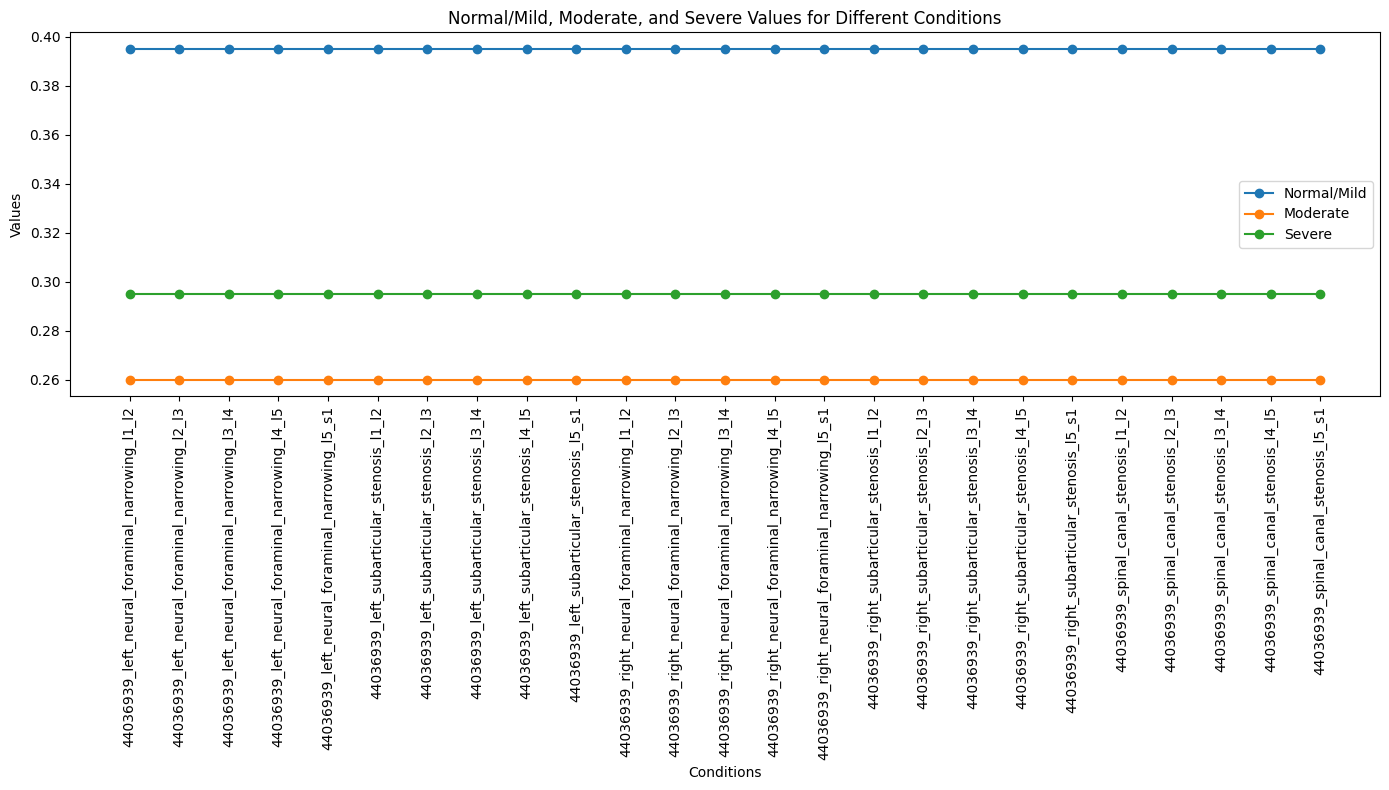

In [30]:
plt.figure(figsize=(14, 8))
plt.plot(df_sub['row_id'], df_sub['normal_mild'], label='Normal/Mild', marker='o')
plt.plot(df_sub['row_id'], df_sub['moderate'], label='Moderate', marker='o')
plt.plot(df_sub['row_id'], df_sub['severe'], label='Severe', marker='o')

plt.xlabel('Conditions')
plt.ylabel('Values')
plt.title('Normal/Mild, Moderate, and Severe Values for Different Conditions')
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()